# Binary Polyhedral Groups Atlas — Walkthrough

This notebook walks through the complete pipeline for constructing the binary polyhedral groups
(2T, 2O, 2I) and synthesizing optimal quantum gate sequences for each group element. Everything
is self-contained — no external imports from `main.py`.

We cover:
1. **Quaternion arithmetic** and the SU(2) representation
2. **Gate definitions** — SU(2) symmetrization and phase tracking
3. **Group construction** — geometric (polytope vertices) and algebraic (Conway & Smith generators)
4. **Synthesis algorithms** — BFS, Dijkstra, and PU(2)
5. **Verification and visualization**

**References:**
- Conway & Smith, *On Quaternions and Octonions* (2003)
- Kubischta & Teixeira, *A Family of Quantum Codes with Exotic Transversal Gates* (2023)

In [1]:
# === Imports and constants ===

import heapq
from collections import deque, defaultdict
from itertools import combinations, product

from sympy import (
    I as symI,
    Matrix,
    Poly,
    Rational,
    Symbol,
    default_sort_key,
    expand,
    radsimp,
    simplify,
    sqrt,
    sympify,
)

import matplotlib.pyplot as plt

SQRT2 = sqrt(2)
SQRT5 = sqrt(5)
SQRT10 = sqrt(10)
TAU = (1 + SQRT5) / 2      # golden ratio (\tau in Conway & Smith)
SIGMA = (SQRT5 - 1) / 2    # inverse golden ratio (\sigma = \tau^{-1})

# Display symbols for golden ratio substitution
_tau_pretty = Symbol('τ')      # renders as \tau
_sig_pretty = Symbol('σ')      # renders as \sigma

# Indeterminates for the basis-reduction polynomial ring (see _to_basis).
_S2 = Symbol('_basis_s2', positive=True)
_S5 = Symbol('_basis_s5', positive=True)


def _to_basis(expr):
    """Express an element of Q(sqrt(2), sqrt(5)) as a 4-tuple of Rationals.

    Returns (a, b, c, d) such that expr = a + b*sqrt(2) + c*sqrt(5) + d*sqrt(10).
    A true canonical form: any two SymPy expressions denoting the same algebraic
    number in Q(sqrt(2), sqrt(5)) produce the same tuple, so tuple equality and
    tuple hashing become exact identity tests.

    The reduction maps sqrt(2), sqrt(5), sqrt(10) onto polynomial indeterminates,
    expands, and folds back the relations sqrt(2)**2 = 2 and sqrt(5)**2 = 5.
    """
    e = sympify(expr)
    e = radsimp(e)
    e = e.xreplace({SQRT2: _S2, SQRT5: _S5, SQRT10: _S2 * _S5})
    e = expand(e)
    poly = Poly(e, _S2, _S5, domain='QQ')

    coeffs = [Rational(0)] * 4   # [1, sqrt(2), sqrt(5), sqrt(10)]
    for (i, j), coef in poly.as_dict().items():
        reduced = Rational(coef) * Rational(2) ** (i // 2) * Rational(5) ** (j // 2)
        idx = (i % 2) + 2 * (j % 2)
        coeffs[idx] += reduced
    return tuple(coeffs)


def _is_zero(expr):
    """Exact zero test for an element of ℚ(√2, √5, i).

    Real and imaginary parts each lie in ℚ(√2, √5), where `_to_basis` is a
    true canonical form — so this decides zero rather than searching for a
    simplification. Raises on an argument outside the field.
    """
    re, im = expand(expr).as_real_imag()
    return all(c == 0 for c in _to_basis(re) + _to_basis(im))


def _golden_sub(expr, tau, sig):
    """Rewrite expr in terms of tau/sigma if it contains sqrt(5).

    Decomposes expr = a + c*sqrt(5) via _to_basis, then uses
    sqrt(5) = 2*tau - 1 = 2*sigma + 1. Prefers whichever form eliminates
    the rational constant. Leaves expressions outside Q(sqrt(5)) untouched.
    """
    e = simplify(expr)
    a, b_s2, c_s5, d_s10 = _to_basis(e)
    if c_s5 == 0:
        return e
    if b_s2 != 0 or d_s10 != 0:
        return e
    if a - c_s5 == 0:
        return 2 * c_s5 * tau
    if a + c_s5 == 0:
        return 2 * c_s5 * sig
    return (a - c_s5) + 2 * c_s5 * tau


def _golden_sub_complex(expr, tau, sig):
    """Apply golden ratio substitution to a complex expression."""
    re, im = expr.as_real_imag()
    re_sub = _golden_sub(re, tau, sig)
    im_sub = _golden_sub(im, tau, sig)
    if im_sub == 0:
        return re_sub
    if re_sub == 0:
        return symI * im_sub
    return re_sub + symI * im_sub


print(f"Golden ratio τ = {float(TAU):.6f}")
print(f"Inverse      σ = {float(SIGMA):.6f}")
print(f"τ * σ = {simplify(TAU * SIGMA)}  (should be 1)")

Golden ratio τ = 1.618034
Inverse      σ = 0.618034
τ * σ = 1  (should be 1)


### Sidebar: a canonical form on $\mathbb{Q}(\sqrt{2}, \sqrt{5})$

The `Quaternion` class below decides identity (`__eq__`, `__hash__`,
`proj_hash`) from `basis_tuple()`, not from the raw SymPy components.
Why the indirection?

SymPy's `simplify` is a *heuristic*, not a normal form: there
is no guarantee that two distinct expressions denoting the same algebraic
number reduce to the same expression tree, and `simplify(x - y) == 0` can
return `False` even when $x = y$ mathematically. Deciding $x = 0$ for
arbitrary symbolic expressions is in fact undecidable (Richardson's
theorem). If we hashed `simplify`-d SymPy trees, BFS/Dijkstra could
"visit" the same group element twice under two different expressions, and
group orders / shortest sequences would silently break.
(Empirically, this doesn't happen for our task; but it pays to be safe.)

Every component of every quaternion in 2T, 2O, 2I lives in
the algebraic number field $\mathbb{Q}(\sqrt{2}, \sqrt{5})$. That field
is a 4-dimensional $\mathbb{Q}$-vector space with natural basis
$\{1, \sqrt{2}, \sqrt{5}, \sqrt{10}\}$, so every element has a *unique*
representation
$$a + b\sqrt{2} + c\sqrt{5} + d\sqrt{10}, \qquad a,b,c,d \in \mathbb{Q}.$$
A tuple of four `Rational`s *is* canonical: tuple equality and
tuple hashing become exact identity tests.

**How `_to_basis` extracts $(a,b,c,d)$:** (see the body in the cell above)
1. `radsimp` rationalizes any irrational denominators (so e.g.
   $1/(1+\sqrt{2}) \to \sqrt{2}-1$).
2. Substitute the surds for polynomial indeterminates
   $\sqrt{2}\to S_2$, $\sqrt{5}\to S_5$, and also
   $\sqrt{10}\to S_2 S_5$ (SymPy auto-collapses $\sqrt{2}\sqrt{5}$ to
   $\sqrt{10}$, so we have to handle that form too).
3. `expand` distributes products; `Poly(..., domain='QQ')` then exposes
   the expression as a polynomial in $S_2, S_5$ with rational coefficients.
4. Fold powers $\ge 2$ back via $S_2^2 = 2$, $S_5^2 = 5$: a monomial
   $S_2^i S_5^j$ contributes $2^{\lfloor i/2 \rfloor} \cdot
   5^{\lfloor j/2 \rfloor}$ to the basis element indexed by
   $(i \bmod 2,\ j \bmod 2)$.

The cell below demonstrates the resulting tuples on a handful of inputs.


In [2]:
# === Demo: _to_basis on representative inputs ===

samples = [
    ("Rational(1, 2)",        Rational(1, 2)),
    ("sqrt(2) / 2",           SQRT2 / 2),
    ("TAU / 2",               TAU / 2),
    ("SIGMA / 2",             SIGMA / 2),
    ("sqrt(10)",              SQRT10),
    ("sqrt(2) * TAU",         SQRT2 * TAU),         # cross-field: lands as sqrt(2)/2 + sqrt(10)/2
    ("1 / (1 + sqrt(2))",     1 / (1 + SQRT2)),     # tests radsimp
    ("(1 + sqrt(2))**2",      (1 + SQRT2) ** 2),    # tests the fold-back: = 3 + 2 sqrt(2)
]

print(f"{'expression':<24} {'(a, b, c, d)':<32} {'== a + b sqrt2 + c sqrt5 + d sqrt10'}")
print("-" * 100)
for label, e in samples:
    a, b, c, d = _to_basis(e)
    rebuilt = a + b * SQRT2 + c * SQRT5 + d * SQRT10
    ok = simplify(e - rebuilt) == 0
    print(f"{label:<24} {str((a, b, c, d)):<32} {simplify(rebuilt)}   {'OK' if ok else 'FAIL'}")


expression               (a, b, c, d)                     == a + b sqrt2 + c sqrt5 + d sqrt10
----------------------------------------------------------------------------------------------------
Rational(1, 2)           (1/2, 0, 0, 0)                   1/2   OK
sqrt(2) / 2              (0, 1/2, 0, 0)                   sqrt(2)/2   OK
TAU / 2                  (1/4, 0, 1/4, 0)                 1/4 + sqrt(5)/4   OK
SIGMA / 2                (-1/4, 0, 1/4, 0)                -1/4 + sqrt(5)/4   OK
sqrt(10)                 (0, 0, 0, 1)                     sqrt(10)   OK
sqrt(2) * TAU            (0, 1/2, 0, 1/2)                 sqrt(2)/2 + sqrt(10)/2   OK
1 / (1 + sqrt(2))        (-1, 1, 0, 0)                    -1 + sqrt(2)   OK
(1 + sqrt(2))**2         (3, 2, 0, 0)                     2*sqrt(2) + 3   OK


## Section 1: Quaternions and SU(2)

Unit quaternions $q = w + xi + yj + zk$ (with $|q| = 1$) are isomorphic to the Lie group SU(2),
which is itself diffeomorphic to the 3-sphere $S^3$.

**Quaternion multiplication** (Hamilton's formula):
$$
(w_1 + x_1 i + y_1 j + z_1 k)(w_2 + x_2 i + y_2 j + z_2 k)
$$
with $i^2 = j^2 = k^2 = ijk = -1$.

**The map to SU(2):** Each unit quaternion $q = w + xi + yj + zk$ corresponds to the unitary matrix
$$
U = \begin{pmatrix} w + ix & y + iz \\ -(y - iz) & w - ix \end{pmatrix}
$$
with $\det(U) = w^2 + x^2 + y^2 + z^2 = 1$.

In [3]:
# === The Quaternion class ===

class Quaternion:
    """Immutable symbolic *unit* quaternion q = w + xi + yj + zk.

    Identity (hashing/equality) is decided by the rational-basis tuple of the
    four components -- see `_to_basis`. The SymPy expression form is kept for
    the math role (multiplication intermediates) and for display.
    """

    __slots__ = ("w", "x", "y", "z", "_hash", "_tuple", "_basis", "_unitary")

    def __init__(self, w, x, y, z):
        self.w = simplify(w)
        self.x = simplify(x)
        self.y = simplify(y)
        self.z = simplify(z)
        self._hash = None
        self._tuple = None
        self._basis = None
        self._unitary = None

    def __mul__(self, other):
        return Quaternion(
            self.w * other.w - self.x * other.x - self.y * other.y - self.z * other.z,
            self.w * other.x + self.x * other.w + self.y * other.z - self.z * other.y,
            self.w * other.y - self.x * other.z + self.y * other.w + self.z * other.x,
            self.w * other.z + self.x * other.y - self.y * other.x + self.z * other.w,
        )

    def conjugate(self):
        """For unit quaternions - elements of SU(2) - the conjugate is the inverse."""
        return Quaternion(self.w, -self.x, -self.y, -self.z)

    def to_unitary(self):
        """Return 2x2 SU(2) matrix: [[a, b], [-b*, a*]] where a = w+ix, b = y+iz."""
        if self._unitary is None:
            a = self.w + symI * self.x
            b = self.y + symI * self.z
            self._unitary = Matrix([
                [a, b],
                [-b.conjugate(), a.conjugate()],
            ])
        return self._unitary

    def to_tuple(self):
        """SymPy-expression view of (w, x, y, z) -- display / sorting only."""
        if self._tuple is None:
            self._tuple = (self.w, self.x, self.y, self.z)
        return self._tuple

    def basis_tuple(self):
        """Canonical identity: a tuple of four rational-coefficient 4-tuples in
        the basis {1, sqrt(2), sqrt(5), sqrt(10)} of Q(sqrt(2), sqrt(5)).
        """
        if self._basis is None:
            self._basis = (
                _to_basis(self.w),
                _to_basis(self.x),
                _to_basis(self.y),
                _to_basis(self.z),
            )
        return self._basis

    def neg(self):
        return Quaternion(-self.w, -self.x, -self.y, -self.z)

    def proj_hash(self):
        """Hash that identifies q and -q (SO(3) / projective equivalence).

        Picks the lexicographic min of the basis tuple and its negation so
        the result is deterministic across runs (independent of Python's
        per-process hash randomization).
        """
        bt = self.basis_tuple()
        neg_bt = tuple(tuple(-x for x in c) for c in bt)
        return hash(min(bt, neg_bt))

    def __eq__(self, other):
        return self.basis_tuple() == other.basis_tuple()

    def __hash__(self):
        if self._hash is None:
            self._hash = hash(self.basis_tuple())
        return self._hash

    def __lt__(self, other):
        """Programmatic ordering only. Permits deterministic sorting of group elements for output/display."""
        return default_sort_key(self.to_tuple()) < default_sort_key(other.to_tuple())

    def __repr__(self):
        return self.pretty()

    def pretty(self):
        def fmt(val):
            val = _golden_sub(val, _tau_pretty, _sig_pretty)
            return str(val).replace("sqrt(2)", "√2").replace(" ", "")
        return f"[{fmt(self.w)}, {fmt(self.x)}, {fmt(self.y)}, {fmt(self.z)}]"

    def pretty_matrix(self):
        U = self.to_unitary()
        def fmt(val):
            val = _golden_sub_complex(val, _tau_pretty, _sig_pretty)
            return str(val).replace("sqrt(2)", "√2").replace("I", "i").replace(" ", "")
        return f"[[{fmt(U[0,0])}, {fmt(U[0,1])}], [{fmt(U[1,0])}, {fmt(U[1,1])}]]"


def _mat_to_quat(U):
    """Convert a 2x2 SU(2) matrix to a unit quaternion."""
    a = U[0, 0]
    b = U[0, 1]
    re_a, im_a = a.as_real_imag()
    re_b, im_b = b.as_real_imag()
    return Quaternion(simplify(re_a), simplify(im_a), simplify(re_b), simplify(im_b))


print("Quaternion class defined.")

Quaternion class defined.


In [4]:
# === Quaternion demo ===

q1 = Quaternion(Rational(1, 2), Rational(1, 2), Rational(1, 2), Rational(1, 2))
q2 = Quaternion(0, 1, 0, 0)  # pure imaginary i
qI = Quaternion(1, 0, 0, 0)  # identity

print("q1 =", q1.pretty())
print("q2 =", q2.pretty())
print()

# Non-commutative multiplication
print("q1 * q2 =", (q1 * q2).pretty())
print("q2 * q1 =", (q2 * q1).pretty())
print("Commutative?", q1 * q2 == q2 * q1)
print()

# Conjugate and inverse
print("q1.conjugate() =", q1.conjugate().pretty())
print("q1 * q1.conjugate() =", (q1 * q1.conjugate()).pretty(), " (should be identity)")
assert q1 * q1.conjugate() == qI
print()

# Unitary matrix
print("q1 as unitary:")
print(q1.to_unitary())

q1 = [1/2, 1/2, 1/2, 1/2]
q2 = [0, 1, 0, 0]

q1 * q2 = [-1/2, 1/2, 1/2, -1/2]
q2 * q1 = [-1/2, 1/2, -1/2, 1/2]
Commutative? False

q1.conjugate() = [1/2, -1/2, -1/2, -1/2]
q1 * q1.conjugate() = [1, 0, 0, 0]  (should be identity)

q1 as unitary:
Matrix([[1/2 + I/2, 1/2 + I/2], [-1/2 + I/2, 1/2 - I/2]])


### The Double Cover: SU(2) $\to$ SO(3)

The quaternions $q$ and $-q$ give the **same** rotation in SO(3). This is the 2-to-1 covering
map SU(2) $\to$ SO(3). Our `proj_hash()` identifies antipodal quaternions.

**Physical significance:** In quantum mechanics, global phase is unphysical. Two unitaries $U$ and
$e^{i\theta} U$ represent the same quantum gate. When we match gates "up to global phase" we are
working in PU(2) rather than SU(2).

**On `proj_hash` determinism.** Because identity is decided from the canonical basis tuple (rather than a Python `hash`), the projective hash is computed as `hash(min(bt, -bt))` -- lexicographic min on the rational coefficients themselves -- so the choice of which of $q$ or $-q$ is the canonical representative is reproducible across runs and independent of Python's per-process hash randomisation.

In [5]:
# === Double cover demo ===

qX = Quaternion(0, 0, 0, -1)   # X gate in SU(2): -iX

print("qX       =", qX.pretty())
print("-qX      =", qX.neg().pretty())
print()
print("qX to unitary =", qX.to_unitary())
print()
print("hash(qX)       =", hash(qX))
print("hash(-qX)      =", hash(qX.neg()))
print("Same hash?      ", hash(qX) == hash(qX.neg()))
print()
print("proj_hash(qX)  =", qX.proj_hash())
print("proj_hash(-qX) =", qX.neg().proj_hash())
print("Same proj_hash? ", qX.proj_hash() == qX.neg().proj_hash())
print()

# X^2 = -I in SU(2) (the double cover!)
X_squared = qX * qX
print("X\u00b2 in SU(2) =", X_squared.pretty(), " (= -I, not I!)")
assert X_squared == Quaternion(-1, 0, 0, 0)

# But proj_hash identifies X^2 with I  (since -I ~ I in PU(2))
print("proj_hash(X\u00b2) == proj_hash(I)?", X_squared.proj_hash() == qI.proj_hash(), " (PU(2) equivalence)")

qX       = [0, 0, 0, -1]
-qX      = [0, 0, 0, 1]

qX to unitary = Matrix([[0, -I], [-I, 0]])

hash(qX)       = -8654148802379373373
hash(-qX)      = 9126503771585831496
Same hash?       False

proj_hash(qX)  = -8654148802379373373
proj_hash(-qX) = -8654148802379373373
Same proj_hash?  True

X² in SU(2) = [-1, 0, 0, 0]  (= -I, not I!)
proj_hash(X²) == proj_hash(I)? True  (PU(2) equivalence)


## Section 2: Gate Definitions

### SU(2) Symmetrization

Standard quantum gates live in U(2), not SU(2). To get a well-defined quaternion
representation we multiply each gate by a phase factor to make $\det = 1$:
$$\mathsf{G}_{SU(2)} = \varphi_\mathsf{G} \cdot \mathsf{G}_{U(2)}$$

**Six gates:**
| Gate | Magic cost | Notes |
|------|-----------|-------|
| X, Z, H, S | 0 | Clifford gates |
| F = HS$^\dagger$ | 0 | Clifford; named for uniformity across groups |
| $\Phi$ | 1 | Golden gate (non-Clifford) |

In [6]:
# === Gate definitions ===

# Standard U(2) gates
_X = Matrix([[0, 1], [1, 0]])
_Z = Matrix([[1, 0], [0, -1]])
_H = (1 / SQRT2) * Matrix([[1, 1], [1, -1]])
_S = Matrix([[1, 0], [0, symI]])
_F = _H * _S.H                   # F = H * S^dagger

_Phi = Rational(1, 2) * Matrix([
    [TAU + symI * SIGMA, 1],
    [-1, TAU - symI * SIGMA],
])

# Symmetrized SU(2) gates: multiply by phase so det = 1
_GX = -symI * _X
_GZ = -symI * _Z
_GH = -symI * _H
_GS = ((1 - symI) / SQRT2) * _S
_GF = _GH * _GS.H
_GPhi = _Phi                      # already has det = 1

# Phase factors: G_SU2 = phase * G_U2
_PHASE_X = -symI
_PHASE_Z = -symI
_PHASE_H = -symI
_PHASE_S = (1 - symI) / SQRT2
_PHASE_F = simplify(_GF[0, 0] / _F[0, 0]) if simplify(_F[0, 0]) != 0 else simplify(_GF[1, 0] / _F[1, 0])
_PHASE_PHI = Rational(1)

# Convert to quaternions
qX = _mat_to_quat(_GX)
qZ = _mat_to_quat(_GZ)
qH = _mat_to_quat(_GH)
qS = _mat_to_quat(_GS)
qF = _mat_to_quat(_GF)
qPhi = _mat_to_quat(_GPhi)

# Gate registry: (quaternion, inverse_quaternion, magic_cost, su2_to_u2_phase)
GATES = {
    "X":  (qX,  qX.conjugate(),  0, _PHASE_X),
    "Z":  (qZ,  qZ.conjugate(),  0, _PHASE_Z),
    "H":  (qH,  qH.conjugate(),  0, _PHASE_H),
    "S":  (qS,  qS.conjugate(),  0, _PHASE_S),
    "F":  (qF,  qF.conjugate(),  0, _PHASE_F),
    "\u03a6":  (qPhi, qPhi.conjugate(), 1, _PHASE_PHI),
}

# Verify phase definitions: phase * G_U2 must equal G_SU2
_U2_GATES = {"X": _X, "Z": _Z, "H": _H, "S": _S, "F": _F, "\u03a6": _Phi}
_SU2_GATES = {"X": _GX, "Z": _GZ, "H": _GH, "S": _GS, "F": _GF, "\u03a6": _GPhi}
for _gn in GATES:
    _phase = GATES[_gn][3]
    _diff = _phase * _U2_GATES[_gn] - _SU2_GATES[_gn]
    assert all(_is_zero(_e) for _e in _diff), f"Phase verification failed for {_gn}"

print("All phase verifications passed.")

All phase verifications passed.


In [7]:
# === Display the gate table ===

print(f"{'Gate':<5} {'Magic':>5}   {'Quaternion':<45} {'Unitary'}")
print("-" * 110)
for name, (q, q_inv, cost, phase) in GATES.items():
    print(f"{name:<5} {cost:>5}   {q.pretty():<45} {q.pretty_matrix()}")

print()
print("Generator sets:")
print("  2T = \u27e8X, Z, F\u27e9")
print("  2O = \u27e8X, Z, F, H, S\u27e9")
print("  2I = \u27e8X, Z, F, \u03a6\u27e9")

Gate  Magic   Quaternion                                    Unitary
--------------------------------------------------------------------------------------------------------------
X         0   [0, 0, 0, -1]                                 [[0, -i], [-i, 0]]
Z         0   [0, -1, 0, 0]                                 [[-i, 0], [0, i]]
H         0   [0, -√2/2, 0, -√2/2]                          [[-√2*i/2, -√2*i/2], [-√2*i/2, √2*i/2]]
S         0   [√2/2, -√2/2, 0, 0]                           [[√2/2-√2*i/2, 0], [0, √2/2+√2*i/2]]
F         0   [1/2, -1/2, -1/2, -1/2]                       [[1/2-i/2, -1/2-i/2], [1/2-i/2, 1/2+i/2]]
Φ         1   [τ/2, σ/2, 1/2, 0]                            [[i*σ/2+τ/2, 1/2], [-1/2, -i*σ/2+τ/2]]

Generator sets:
  2T = ⟨X, Z, F⟩
  2O = ⟨X, Z, F, H, S⟩
  2I = ⟨X, Z, F, Φ⟩


In [8]:
# === Build gate lists for synthesizers ===

def _gate_list_bfs(names):
    """Build gate list for BFS synthesizer -- generators and adjoints."""
    gates = []
    for name in names:
        q, q_inv, _cost, _phase = GATES[name]
        gates.append((name, q))
        gates.append((name + "\u2020", q_inv))
    return gates


def _gate_list_dijkstra(names):
    """Build gate list for Dijkstra synthesizer (with magic cost)."""
    gates = []
    for name in names:
        q, q_inv, cost, _phase = GATES[name]
        gates.append((name, q, cost))
        gates.append((name + "\u2020", q_inv, cost))
    return gates


# BFS gate sets
GATES_BFS_2T = _gate_list_bfs(["X", "Z", "F"])
GATES_BFS_2O = _gate_list_bfs(["X", "Z", "F", "H", "S"])
GATES_BFS_2I = _gate_list_bfs(["X", "Z", "F", "\u03a6"])

# Dijkstra gate sets
GATES_DIJ_2T = _gate_list_dijkstra(["X", "Z", "F"])
GATES_DIJ_2O = _gate_list_dijkstra(["X", "Z", "F", "H", "S"])
GATES_DIJ_2I = _gate_list_dijkstra(["X", "Z", "F", "\u03a6"])

# PU(2) gate sets (same as BFS; the difference is in the synthesis algorithm)
GATES_U2_2T = _gate_list_bfs(["X", "Z", "F"])
GATES_U2_2O = _gate_list_bfs(["X", "Z", "F", "H", "S"])
GATES_U2_2I = _gate_list_bfs(["X", "Z", "F", "\u03a6"])

print(f"BFS 2T: {len(GATES_BFS_2T)} gates (generators + adjoints)")
print(f"BFS 2I: {len(GATES_BFS_2I)} gates")
print(f"Dijkstra 2I: {len(GATES_DIJ_2I)} gates (with magic costs)")

BFS 2T: 6 gates (generators + adjoints)
BFS 2I: 8 gates
Dijkstra 2I: 8 gates (with magic costs)


## Section 3: Group Construction

### Geometric Construction (Polytope Vertices)

The binary polyhedral groups are the vertices of certain 4D regular polytopes living on $S^3$:

- **2T** (order 24): vertices of the 24-cell — 8 axis-aligned unit quaternions, i.e., the 8 elements formed by all coordinate permutations of $(\pm 1, 0, 0, 0)$, plus 16 half-integer quaternions $(\pm\frac{1}{2} \pm \frac{1}{2}i \pm \frac{1}{2}j \pm \frac{1}{2}k)$
- **2O** (order 48): 2T plus 24 dual 24-cell vertices (pairs of $\pm\frac{1}{\sqrt{2}}$ in two coordinates, i.e., all coordinate permutations of $(\pm \frac{1}{\sqrt{2}}, \pm \frac{1}{\sqrt{2}}, 0, 0)$)
- **2I** (order 120): 2T plus 96 vertices from even permutations of $(\frac{1}{2}, \frac{\tau}{2}, \frac{\sigma}{2}, 0)$ with all sign combinations

In [9]:
# === Geometric group construction ===

def geometric_group(mode):
    """Generate group elements as quaternions from 4D polytope geometry."""
    qs = []

    # 2T core: 8 axis-aligned + 16 half-integer quaternions
    for i in range(4):
        for s in [1, -1]:
            v = [0] * 4
            v[i] = s
            qs.append(Quaternion(*v))
    for s in product([Rational(1, 2), Rational(-1, 2)], repeat=4):
        qs.append(Quaternion(*s))

    if mode == "2T":
        return qs

    if mode == "2O":
        val = 1 / SQRT2
        for idx in combinations(range(4), 2):
            for s in product([1, -1], repeat=2):
                v = [0] * 4
                v[idx[0]] = s[0] * val
                v[idx[1]] = s[1] * val
                qs.append(Quaternion(*v))
        return qs

    if mode == "2I":
        vals = [Rational(1, 2), TAU / 2, SIGMA / 2, 0]
        even_perms = [
            (0, 1, 2, 3), (0, 2, 3, 1), (0, 3, 1, 2),
            (1, 0, 3, 2), (1, 2, 0, 3), (1, 3, 2, 0),
            (2, 0, 1, 3), (2, 1, 3, 0), (2, 3, 0, 1),
            (3, 0, 2, 1), (3, 1, 0, 2), (3, 2, 1, 0),
        ]
        seen = {hash(q) for q in qs}
        for p in even_perms:
            p_vals = [vals[p[i]] for i in range(4)]
            zero_pos = p.index(3)
            for signs in product([1, -1], repeat=3):
                v = [0] * 4
                s_ptr = 0
                for i in range(4):
                    if i == zero_pos:
                        continue
                    v[i] = p_vals[i] * signs[s_ptr]
                    s_ptr += 1
                q = Quaternion(*v)
                if hash(q) not in seen:
                    qs.append(q)
                    seen.add(hash(q))
        return qs

    raise ValueError(f"Unknown mode: {mode}")


g2T = geometric_group("2T")
g2O = geometric_group("2O")
g2I = geometric_group("2I")

print(f"|2T| = {len(g2T)}  (expected 24)")
print(f"|2O| = {len(g2O)}  (expected 48)")
print(f"|2I| = {len(g2I)}  (expected 120)")
print()
print("First 5 elements of 2T:")
for q in g2T[:5]:
    print(f"  {q.pretty()}")

|2T| = 24  (expected 24)
|2O| = 48  (expected 48)
|2I| = 120  (expected 120)

First 5 elements of 2T:
  [1, 0, 0, 0]
  [-1, 0, 0, 0]
  [0, 1, 0, 0]
  [0, -1, 0, 0]
  [0, 0, 1, 0]


### Algebraic Construction (Conway & Smith)

Conway & Smith (2003), Theorem 12: each binary polyhedral group is generated by a shared
generator $w = \frac{-1+i+j+k}{2}$ and a group-specific generator:
- $i_T = i$ for 2T
- $i_O = \frac{j+k}{\sqrt{2}}$ for 2O
- $i_I = \frac{i + \sigma j + \tau k}{2}$ for 2I

The group is the BFS closure: multiply known elements by generators until no new elements appear.

In [10]:
# === Algebraic (Conway & Smith) group construction ===

def conway_group(mode):
    """Generate group via closure of Conway & Smith generators (Theorem 12)."""
    gen_w = Quaternion(Rational(-1, 2), Rational(1, 2), Rational(1, 2), Rational(1, 2))

    gen_map = {
        "2T": Quaternion(0, 1, 0, 0),
        "2O": Quaternion(0, 0, 1 / SQRT2, 1 / SQRT2),
        "2I": Quaternion(0, Rational(1, 2), SIGMA / 2, TAU / 2),
    }

    generators = [gen_w, gen_map[mode]]
    group = set(generators)
    queue = list(generators)
    hashes = {hash(g) for g in generators}

    while queue:
        curr = queue.pop(0)
        for g in generators:
            for prod in [curr * g, g * curr]:
                h = hash(prod)
                if h not in hashes:
                    hashes.add(h)
                    group.add(prod)
                    queue.append(prod)

    return list(group)


c2T = conway_group("2T")
c2O = conway_group("2O")
c2I = conway_group("2I")

print(f"|2T| = {len(c2T)}  (expected 24)")
print(f"|2O| = {len(c2O)}  (expected 48)")
print(f"|2I| = {len(c2I)}  (expected 120)")

|2T| = 24  (expected 24)
|2O| = 48  (expected 48)
|2I| = 120  (expected 120)


In [11]:
# === Verification: geometric == algebraic ===

def verify_group(mode):
    """Verify that geometric and algebraic constructions produce the same group."""
    g_geom = geometric_group(mode)
    g_conway = conway_group(mode)

    expected_orders = {"2T": 24, "2O": 48, "2I": 120}
    expected = expected_orders[mode]

    set_geom = {hash(q) for q in g_geom}
    set_conway = {hash(q) for q in g_conway}

    assert len(set_geom) == expected, f"{mode} geometric: expected {expected}, got {len(set_geom)}"
    assert len(set_conway) == expected, f"{mode} Conway: expected {expected}, got {len(set_conway)}"
    assert set_geom == set_conway, f"{mode}: geometric and Conway groups differ"

    print(f"  \u2713 {mode}: order {expected}, geometric = algebraic")


for mode in ["2T", "2O", "2I"]:
    verify_group(mode)

  ✓ 2T: order 24, geometric = algebraic


  ✓ 2O: order 48, geometric = algebraic


  ✓ 2I: order 120, geometric = algebraic


### Bridge to Synthesis

Now that we have the groups, the question becomes: **what is the shortest gate circuit that
produces each element?** We have three synthesis algorithms, each optimizing for a different
physical objective.

## Section 4: Synthesis Algorithms

### BFS Synthesis (Minimum Depth)

Breadth-first search from the identity, applying generators and their adjoints at each level.
The first time we reach a target quaternion gives the minimum circuit depth.

The generators are the canonical Kubischta & Teixeira ones; the search is ours. The dagger (†) denotes the algebraic inverse in this SU(2) representation.

In [12]:
# === BFS Synthesis ===

def synthesize_bfs(target_quats, gates, max_depth=12):
    """
    Find shortest gate sequences for each target quaternion via BFS.
    Returns dict mapping hash(q) -> (sequence, depth).
    """
    targets = {hash(q) for q in target_quats}
    results = {}

    qI = Quaternion(1, 0, 0, 0)
    visited = {hash(qI): []}
    queue = deque([(qI, [])])

    while queue and len(results) < len(targets):
        curr, path = queue.popleft()
        h = hash(curr)

        if h in targets and h not in results:
            results[h] = (path, len(path))

        if len(path) >= max_depth:
            continue

        for name, g_q in gates:
            new_q = curr * g_q
            nh = hash(new_q)
            if nh not in visited:
                new_path = path + [name]
                visited[nh] = new_path
                queue.append((new_q, new_path))

    return results


# Run on 2T
bfs_2T = synthesize_bfs(g2T, GATES_BFS_2T)
print(f"BFS found {len(bfs_2T)}/{len(g2T)} elements of 2T")

BFS found 24/24 elements of 2T


In [13]:
# === Explore BFS results on 2T ===

def format_seq(seq):
    """Format a gate sequence for display."""
    if not seq:
        return "I"
    return " ".join(seq)


# Depth histogram
from collections import Counter
depths_2T = Counter()
for h, (seq, dep) in bfs_2T.items():
    depths_2T[dep] += 1

print("2T depth distribution:")
for d in sorted(depths_2T):
    print(f"  depth {d}: {depths_2T[d]} elements")
print()

# Print all 24 elements sorted by depth
rows = []
for q in g2T:
    h = hash(q)
    if h in bfs_2T:
        seq, dep = bfs_2T[h]
        rows.append((dep, format_seq(seq), q.pretty()))

rows.sort()
print(f"{'Dep':<4} {'Sequence':<20} {'Quaternion'}")
print("-" * 70)
for dep, seq_str, qstr in rows:
    print(f"{dep:<4} {seq_str:<20} {qstr}")

2T depth distribution:
  depth 0: 1 elements
  depth 1: 6 elements
  depth 2: 17 elements

Dep  Sequence             Quaternion
----------------------------------------------------------------------
0    I                    [1, 0, 0, 0]
1    F                    [1/2, -1/2, -1/2, -1/2]
1    F†                   [1/2, 1/2, 1/2, 1/2]
1    X                    [0, 0, 0, -1]
1    X†                   [0, 0, 0, 1]
1    Z                    [0, -1, 0, 0]
1    Z†                   [0, 1, 0, 0]
2    F F                  [-1/2, -1/2, -1/2, -1/2]
2    F X                  [-1/2, 1/2, -1/2, -1/2]
2    F X†                 [1/2, -1/2, 1/2, 1/2]
2    F† F†                [-1/2, 1/2, 1/2, 1/2]
2    F† Z                 [1/2, -1/2, -1/2, 1/2]
2    F† Z†                [-1/2, 1/2, 1/2, -1/2]
2    X F                  [-1/2, -1/2, 1/2, -1/2]
2    X F†                 [1/2, 1/2, -1/2, -1/2]
2    X X                  [-1, 0, 0, 0]
2    X Z                  [0, 0, 1, 0]
2    X Z†                 [0, 0, -

### Dijkstra Synthesis (Minimum Magic Cost)

Non-Clifford gates (like $\Phi$) are extremely expensive in fault-tolerant quantum computing
because they require magic state distillation. Dijkstra's algorithm minimizes
$(\text{magic\_cost}, \text{depth})$ lexicographically.

For all-Clifford groups (2T, 2O), this reduces to BFS since all gates have zero magic cost.
The interesting case is **2I**, where $\Phi$ has magic cost 1.

In [14]:
# === Dijkstra Synthesis ===

def synthesize_dijkstra(target_quats, gates, max_depth=12):
    """
    Find optimal gate sequences for each target quaternion.
    Optimizes first by magic cost, then by depth.
    Returns dict mapping hash(q) -> (sequence, magic_cost, depth).
    """
    targets = {hash(q) for q in target_quats}
    results = {}

    qI = Quaternion(1, 0, 0, 0)
    counter = 0
    pq = [(0, 0, counter, qI, [])]
    best_cost = {hash(qI): (0, 0)}

    while pq and len(results) < len(targets):
        mag, dep, _cnt, curr, path = heapq.heappop(pq)
        h = hash(curr)

        bm, bd = best_cost.get(h, (999, 999))
        if mag > bm or (mag == bm and dep > bd):
            continue

        if h in targets and h not in results:
            results[h] = (list(path), mag, dep)

        if dep >= max_depth:
            continue

        for name, g_q, g_cost in gates:
            new_q = curr * g_q
            nh = hash(new_q)
            nm, nd = mag + g_cost, dep + 1

            prev_m, prev_d = best_cost.get(nh, (999, 999))
            if nm < prev_m or (nm == prev_m and nd < prev_d):
                best_cost[nh] = (nm, nd)
                counter += 1
                heapq.heappush(pq, (nm, nd, counter, new_q, path + [name]))

    return results


print("Dijkstra synthesizer defined.")

Dijkstra synthesizer defined.


In [15]:
# === BFS vs Dijkstra on 2I -- the interesting comparison ===

print("Synthesizing 2I (this may take a few seconds)...")
bfs_2I = synthesize_bfs(g2I, GATES_BFS_2I)
dij_2I = synthesize_dijkstra(g2I, GATES_DIJ_2I)
print(f"BFS found {len(bfs_2I)}/120, Dijkstra found {len(dij_2I)}/120")
print()

# Find elements where the sequences differ
diffs = []
for q in g2I:
    h = hash(q)
    if h in bfs_2I and h in dij_2I:
        bfs_seq, bfs_dep = bfs_2I[h]
        dij_seq, dij_mag, dij_dep = dij_2I[h]
        bfs_magic = sum(1 for g in bfs_seq if g.rstrip("\u2020") == "\u03a6")
        if bfs_seq != dij_seq:
            diffs.append((q, bfs_seq, bfs_dep, bfs_magic, dij_seq, dij_dep, dij_mag))

diffs.sort(key=lambda t: t[2])  # sort by BFS depth

if diffs:
    print(f"{len(diffs)} elements have different BFS vs Dijkstra sequences:")
    print()
    print(f"{'Quaternion':<40} {'BFS seq':<20} {'dep':>3} {'mag':>3}   {'Dij seq':<20} {'dep':>3} {'mag':>3}")
    print("-" * 105)
    for q, bs, bd, bm, ds, dd, dm in diffs[:20]:  # show first 20
        print(f"{q.pretty():<40} {format_seq(bs):<20} {bd:>3} {bm:>3}   {format_seq(ds):<20} {dd:>3} {dm:>3}")
    if len(diffs) > 20:
        print(f"  ... and {len(diffs) - 20} more")
else:
    print("All sequences are identical (this is expected for all-Clifford groups).")

Synthesizing 2I (this may take a few seconds)...


BFS found 120/120, Dijkstra found 120/120

17 elements have different BFS vs Dijkstra sequences:

Quaternion                               BFS seq              dep mag   Dij seq              dep mag
---------------------------------------------------------------------------------------------------------
[σ/2, 1/2, τ/2, 0]                       Φ Φ                    2   2   F X Φ† Z               4   1
[σ/2, -1/2, -τ/2, 0]                     Φ† Φ†                  2   2   X Z† Φ† F†             4   1
[-1/2, -τ/2, σ/2, 0]                     X Φ† F                 3   1   X† F† Φ                3   1
[1/2, -σ/2, 0, -τ/2]                     Z Φ Φ                  3   2   Φ† Z F†                3   1
[-1/2, σ/2, 0, τ/2]                      Z† Φ Φ                 3   2   Φ† Z† F†               3   1
[τ/2, 1/2, 0, -σ/2]                      F Φ Φ                  3   2   Φ† Z† F                3   1
[τ/2, 0, σ/2, -1/2]                      Z Φ F†                 3   1   Z† F Φ†          

### PU(2) Synthesis (Matching Up to Global Phase)

Since global phase is unphysical in quantum mechanics, we can match targets up to
$q \equiv -q$. This uses `proj_hash` instead of `hash`.

The result: 12 entries for 2T (not 24), 24 for 2O (not 48), 60 for 2I (not 120) —
one per antipodal pair.

In [16]:
# === PU(2) Synthesis ===

def synthesize_u2(target_quats, gates, max_depth=12):
    """
    Find shortest gate sequences matching each target up to global phase.
    Uses proj_hash (identifying q and -q) so that e.g. X^2 = I in PU(2).
    Returns dict mapping proj_hash(q) -> (sequence, depth).
    """
    targets = {q.proj_hash() for q in target_quats}
    results = {}

    qI = Quaternion(1, 0, 0, 0)
    visited = {qI.proj_hash(): []}
    queue = deque([(qI, [])])

    while queue and len(results) < len(targets):
        curr, path = queue.popleft()
        ph = curr.proj_hash()

        if ph in targets and ph not in results:
            results[ph] = (path, len(path))

        if len(path) >= max_depth:
            continue

        for name, g_q in gates:
            new_q = curr * g_q
            nph = new_q.proj_hash()
            if nph not in visited:
                new_path = path + [name]
                visited[nph] = new_path
                queue.append((new_q, new_path))

    return results


print("PU(2) synthesizer defined.")

PU(2) synthesizer defined.


In [17]:
# === PU(2) demo ===

u2_2T = synthesize_u2(g2T, GATES_U2_2T)
print(f"PU(2) synthesis of 2T: {len(u2_2T)} entries (= {len(g2T)//2} antipodal pairs, not {len(g2T)})")
print()

# Show an antipodal pair covered by one PU(2) sequence
# Find qX and -qX (redefine from gates)
qX_gate = GATES["X"][0]
qX_neg = qX_gate.neg()

print(f"qX       = {qX_gate.pretty()}")
print(f"-qX      = {qX_neg.pretty()}")
print(f"proj_hash match: {qX_gate.proj_hash() == qX_neg.proj_hash()}")
print()

ph = qX_gate.proj_hash()
if ph in u2_2T:
    seq, dep = u2_2T[ph]
    print(f"PU(2) sequence for this pair: {format_seq(seq)} (depth {dep})")
    print("This single sequence covers both qX and -qX.")

PU(2) synthesis of 2T: 12 entries (= 12 antipodal pairs, not 24)

qX       = [0, 0, 0, -1]
-qX      = [0, 0, 0, 1]
proj_hash match: True

PU(2) sequence for this pair: X (depth 1)
This single sequence covers both qX and -qX.


## Section 5: Verification & Output

### Replay Verification

Every synthesized sequence is replayed — we multiply the gate quaternions left to right
and check that the result matches the target.

In [18]:
# === Replay verification ===

def _replay_sequence(seq):
    """Multiply out a gate sequence to get the resulting quaternion."""
    result = Quaternion(1, 0, 0, 0)  # identity
    for name in seq:
        base = name.rstrip("\u2020")
        is_dag = name.endswith("\u2020")
        q, q_inv, _cost, _phase = GATES[base]
        result = result * (q_inv if is_dag else q)
    return result


# Demo: replay a specific sequence
demo_q = g2T[5]  # pick an element
h = hash(demo_q)
if h in bfs_2T:
    demo_seq, demo_dep = bfs_2T[h]
    replayed = _replay_sequence(demo_seq)
    print(f"Target:   {demo_q.pretty()}")
    print(f"Sequence: {format_seq(demo_seq)} (depth {demo_dep})")
    print(f"Replay:   {replayed.pretty()}")
    print(f"Match:    {replayed == demo_q}")
    assert replayed == demo_q

Target:   [0, 0, -1, 0]
Sequence: X Z† (depth 2)
Replay:   [0, 0, -1, 0]
Match:    True


In [19]:
# === Full pipeline verification ===

def _compute_u2_phase(seq, q_target):
    """Compute exact phase phi such that the PU(2) sequence = phi * q_target."""
    q_su2 = _replay_sequence(seq) if seq else Quaternion(1, 0, 0, 0)

    if q_su2 == q_target:
        sign = Rational(1)
    elif q_su2 == q_target.neg():
        sign = Rational(-1)
    else:
        raise ValueError(f"PU(2) sequence does not match target up to sign")

    accumulated = Rational(1)
    for name in seq:
        base = name.rstrip("\u2020")
        is_dag = name.endswith("\u2020")
        _q, _q_inv, _cost, phase = GATES[base]
        gate_phase = phase.conjugate() if is_dag else phase
        accumulated *= gate_phase

    return simplify(sign / accumulated)


def generate_group_data(mode, bfs_gates, dij_gates, u2_gates):
    """Generate full table data for one group."""
    quats = geometric_group(mode)
    bfs_results = synthesize_bfs(quats, bfs_gates)
    dij_results = synthesize_dijkstra(quats, dij_gates)
    u2_results = synthesize_u2(quats, u2_gates)

    rows = []
    for q in quats:
        h = hash(q)
        ph = q.proj_hash()

        if h in bfs_results:
            bfs_seq, bfs_dep = bfs_results[h]
        else:
            bfs_seq, bfs_dep = ["?"], -1

        if h in dij_results:
            dij_seq, dij_mag, dij_dep = dij_results[h]
        else:
            dij_seq, dij_mag, dij_dep = ["?"], -1, -1

        if ph in u2_results:
            u2_seq, u2_dep = u2_results[ph]
            u2_phase = _compute_u2_phase(u2_seq, q)
        else:
            u2_seq, u2_dep = ["?"], -1
            u2_phase = None

        rows.append({
            "quat": q,
            "bfs_seq": bfs_seq,
            "bfs_depth": bfs_dep,
            "dij_seq": dij_seq,
            "dij_magic": dij_mag,
            "dij_depth": dij_dep,
            "u2_seq": u2_seq,
            "u2_depth": u2_dep,
            "u2_phase": u2_phase,
        })

    rows.sort(key=lambda r: (r["bfs_depth"], str(r["bfs_seq"])))
    return rows


def _pair_antipodal_rows(rows):
    """Group rows into (q, -q) pairs for double cover display."""
    groups = defaultdict(list)
    for row in rows:
        groups[row["quat"].proj_hash()].append(row)

    pairs = []
    for pair_rows in groups.values():
        assert len(pair_rows) == 2, f"Expected pair, got {len(pair_rows)}"
        pair_rows.sort(key=lambda r: (r["bfs_depth"], str(r["bfs_seq"])))
        pairs.append((pair_rows[0], pair_rows[1]))

    pairs.sort(key=lambda p: (p[0]["bfs_depth"], str(p[0]["bfs_seq"])))
    return pairs


# Run full pipeline and verify for all groups
print("Running full pipeline for all three groups...")

runs = [
    ("2T", GATES_BFS_2T, GATES_DIJ_2T, GATES_U2_2T),
    ("2O", GATES_BFS_2O, GATES_DIJ_2O, GATES_U2_2O),
    ("2I", GATES_BFS_2I, GATES_DIJ_2I, GATES_U2_2I),
]

all_data = {}
for mode, bfs_g, dij_g, u2_g in runs:
    rows = generate_group_data(mode, bfs_g, dij_g, u2_g)
    pairs = _pair_antipodal_rows(rows)
    all_data[mode] = (rows, pairs)

    # Verify: replay every BFS and Dijkstra sequence
    errors = 0
    for row in rows:
        q = row["quat"]
        if row["bfs_depth"] >= 0:
            got = _replay_sequence(row["bfs_seq"])
            if got != q:
                errors += 1
        if row["dij_depth"] >= 0:
            got = _replay_sequence(row["dij_seq"])
            if got != q:
                errors += 1
        if row["u2_depth"] >= 0:
            got = _replay_sequence(row["u2_seq"])
            if got.proj_hash() != q.proj_hash():
                errors += 1

    status = "\u2713" if errors == 0 else "\u2717"
    print(f"  {status} {mode}: {len(rows)} elements, {len(pairs)} pairs, {errors} replay errors")

assert all(
    all(r["bfs_depth"] >= 0 and r["dij_depth"] >= 0 and r["u2_depth"] >= 0
        for r in data[0])
    for data in all_data.values()
), "Some elements were not synthesized!"
print("\nAll synthesis results verified.")

Running full pipeline for all three groups...


  ✓ 2T: 24 elements, 12 pairs, 0 replay errors


  ✓ 2O: 48 elements, 24 pairs, 0 replay errors


  ✓ 2I: 120 elements, 60 pairs, 0 replay errors

All synthesis results verified.


## Section 6: Visualization & Summary

### Depth and Magic Cost Distribution

How complex are the circuits? Let's visualize the distribution of BFS depth across all three
groups, and for 2I, compare the magic cost distribution between BFS and Dijkstra.

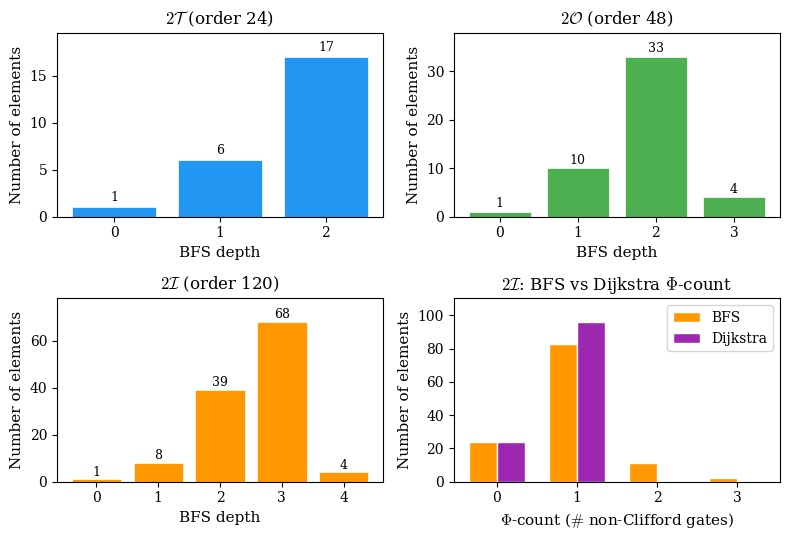

Figure saved to bpg_distributions.pdf


In [20]:
# === Visualization (publication quality) ===

import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

_mode_labels = {
    "2T": r"$2\mathcal{T}$ (order 24)",
    "2O": r"$2\mathcal{O}$ (order 48)",
    "2I": r"$2\mathcal{I}$ (order 120)",
}

fig, axes = plt.subplots(2, 2, figsize=(8, 5.5))

# BFS depth distributions for 2T, 2O, 2I
for ax, mode, color in zip(axes[0, :2].tolist() + [axes[1, 0]], ["2T", "2O", "2I"],
                            ["#2196F3", "#4CAF50", "#FF9800"]):
    rows = all_data[mode][0]
    depths = [r["bfs_depth"] for r in rows]
    depth_counts = Counter(depths)
    ds = sorted(depth_counts.keys())
    counts = [depth_counts[d] for d in ds]
    ax.bar(ds, counts, color=color, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("BFS depth")
    ax.set_ylabel("Number of elements")
    ax.set_title(_mode_labels[mode])
    ax.set_xticks(ds)
    ax.set_ylim(0, max(counts) * 1.15)
    for d, c in zip(ds, counts):
        ax.text(d, c + 0.3, str(c), ha="center", va="bottom", fontsize=9)

# 2I: Dijkstra magic cost distribution
ax = axes[1, 1]
rows_2I = all_data["2I"][0]
bfs_magic = [sum(1 for g in r["bfs_seq"] if g.rstrip("\u2020") == "\u03a6") for r in rows_2I]
dij_magic = [r["dij_magic"] for r in rows_2I]

bfs_mc = Counter(bfs_magic)
dij_mc = Counter(dij_magic)
all_costs = sorted(set(bfs_mc.keys()) | set(dij_mc.keys()))
x = range(len(all_costs))
w = 0.35

bars_bfs = [bfs_mc.get(c, 0) for c in all_costs]
bars_dij = [dij_mc.get(c, 0) for c in all_costs]
ax.bar([i - w/2 for i in x], bars_bfs,
       width=w, label="BFS", color="#FF9800", edgecolor="white")
ax.bar([i + w/2 for i in x], bars_dij,
       width=w, label="Dijkstra", color="#9C27B0", edgecolor="white")
ax.set_xlabel(r"$\Phi$-count ($\#$ non-Clifford gates)")
ax.set_ylabel("Number of elements")
ax.set_title(r"$2\mathcal{I}$: BFS vs Dijkstra $\Phi$-count")
ax.set_xticks(list(x))
ax.set_xticklabels([str(c) for c in all_costs])
ax.set_ylim(0, max(max(bars_bfs), max(bars_dij)) * 1.15)
ax.legend()

plt.tight_layout()
plt.savefig("bpg_distributions.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to bpg_distributions.pdf")

### Summary & Key Takeaways

1. **Three construction methods produce identical groups.** The geometric (polytope vertex)
   and algebraic (Conway & Smith generator closure) constructions agree perfectly for all
   three groups.

2. **Three synthesizers serve different physical purposes:**
   - **BFS** minimizes circuit depth (fewest gates)
   - **Dijkstra** minimizes magic cost, then depth (cheapest fault-tolerant implementation)
   - **PU(2)** matches up to global phase (physically equivalent circuits)

3. **2T and 2O are entirely Clifford** — BFS and Dijkstra give identical results since all
   gates have zero magic cost.

4. **2I has a depth-magic tradeoff** — Dijkstra sometimes finds longer but cheaper (fewer $\Phi$)
   sequences than BFS.

5. The full atlas with all gate sequences is in the thesis appendix.

In [21]:
# === Summary statistics ===

print(f"{'Group':<6} {'Order':>5} {'Pairs':>5} {'Max BFS dep':>12} {'Max Dij mag':>12} {'# non-Cliff pairs':>18}")
print("-" * 65)
for mode in ["2T", "2O", "2I"]:
    rows, pairs = all_data[mode]
    order = len(rows)
    n_pairs = len(pairs)
    max_bfs = max(r["bfs_depth"] for r in rows)
    max_dij_mag = max(r["dij_magic"] for r in rows)
    # Non-Clifford pairs: at least one element needs a non-Clifford gate
    nc_pairs = sum(
        1 for p, a in pairs
        if p["dij_magic"] > 0 or a["dij_magic"] > 0
    )
    print(f"{mode:<6} {order:>5} {n_pairs:>5} {max_bfs:>12} {max_dij_mag:>12} {nc_pairs:>18}")

Group  Order Pairs  Max BFS dep  Max Dij mag  # non-Cliff pairs
-----------------------------------------------------------------
2T        24    12            2            0                  0
2O        48    24            3            0                  0
2I       120    60            4            1                 48
